In [1]:
import pandas as pd


In [3]:
pd.read_csv("data/Jumlah Penumpang Kereta Api, 2016.csv")

,Unnamed: 0,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tahunan
0,Jabodetabek,22238,21229,23206,23149,24401,23821,21574,23923,23570,24533,24104,24841,-
1,Non Jabodetabek (Jawa),5648,4829,4950,4851,5775,4909,6642,5202,5448,5232,5074,6689,-
2,Jawa (Jabodetabek+Non Jabodetabek),27886,26058,28156,28000,30176,28730,28216,29125,29019,29765,29178,31530,-
3,Non Jawa (Sumatera + Sulawesi),472,453,461,434,527,429,615,463,497,498,512,620,-
4,Kereta Bandara,-,-,-,-,-,-,-,-,-,-,-,-,-
5,MRT,-,-,-,-,-,-,-,-,-,-,-,-,-
6,LRT,-,-,-,-,-,-,-,-,-,-,-,-,-
7,Kereta cepat (Whoosh),-,-,-,-,-,-,-,-,-,-,-,-,-
8,Total,28358,26510,28617,28435,30703,29159,28831,29588,29516,30263,29690,32150,-


In [4]:
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\Carol\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.stats import gaussian_kde


In [7]:
month_map = {
    "Januari": 1,
    "Februari": 2,
    "Maret": 3,
    "April": 4,
    "Mei": 5,
    "Juni": 6,
    "Juli": 7,
    "Agustus": 8,
    "September": 9,
    "Oktober": 10,
    "November": 11,
    "Desember": 12
}

list_data = []

for file in sorted(glob.glob("data/*.csv")):
    with open(file, "r", encoding="utf-8") as f:
        lines = [f.readline() for _ in range(3)]
        tahun = re.sub(r"[^0-9]", "", lines[2])
    if not tahun:
        continue

    df = pd.read_csv(file, skiprows=3)
    df = df.rename(columns={df.columns[0]: "Kategori"})

    if "Tahunan" in df.columns:
        df = df.drop(columns=["Tahunan"])

    df_long = df.melt(
        id_vars=["Kategori"], var_name="Bulan", value_name="Jumlah Penumpang"

    )

    df_long["Tahun"] = tahun

    df_long["Jumlah Penumpang"] = pd.to_numeric(df_long["Jumlah Penumpang"].astype(str).str.replace("-", "0"), errors="coerce",).fillna(0)
    list_data.append(df_long)

C:\Users\Carol\AppData\Local\Temp\ipykernel_16632\1289726859.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_order, rotation=45, ha='right', fontsize=9)
C:\Users\Carol\AppData\Local\Temp\ipykernel_16632\1289726859.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_order, rotation=45, ha='right', fontsize=9)
C:\Users\Carol\AppData\Local\Temp\ipykernel_16632\1289726859.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_order, rotation=45, ha='right', fontsize=9)
C:\Users\Carol\AppData\Local\Temp\ipykernel_16632\1289726859.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a

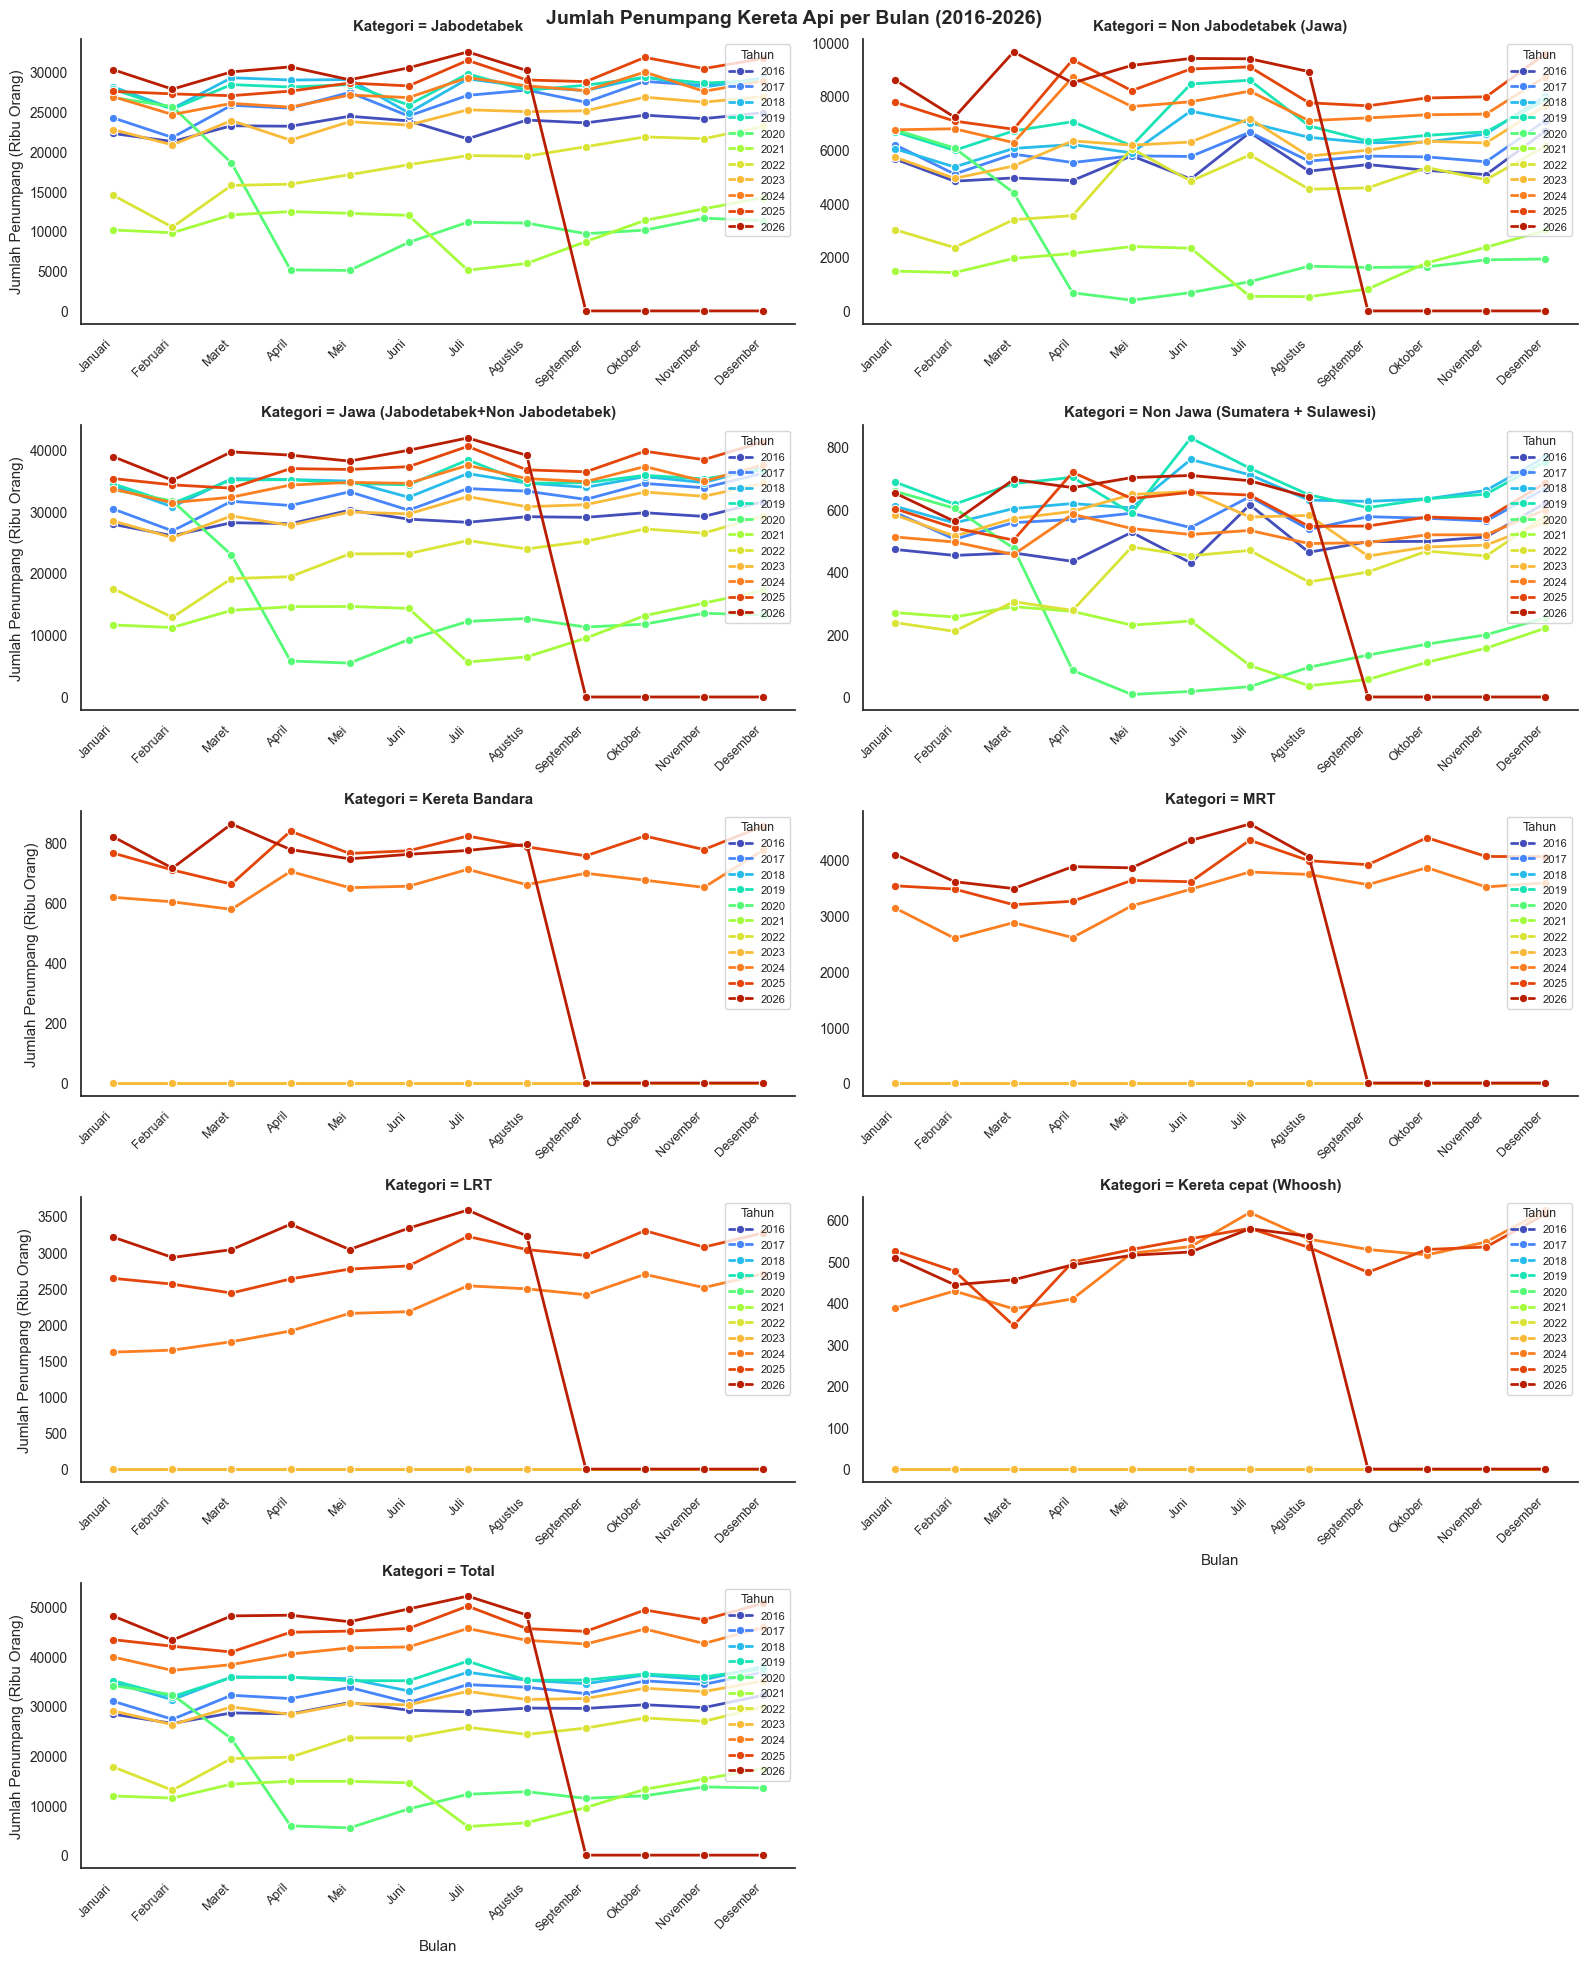

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
month_order = [
    'Januari',
    'Februari',
    'Maret',
    'April',
    'Mei',
    'Juni',
    'Juli',
    'Agustus',
    'September',
    'Oktober',
    'November',
    'Desember',
]
data_utama['Bulan'] = pd.Categorical(
    data_utama['Bulan'], categories=month_order, ordered=True
)
g = sns.FacetGrid(
    data=data_utama,
    col='Kategori',
    hue='Tahun',
    col_wrap=2,
    height=4,
    aspect=2,
    sharey=False,
    sharex=False,
    palette='turbo',
)

g.map_dataframe(
    sns.lineplot, x='Bulan', y='Jumlah Penumpang', marker='o', linewidth=2
)
for ax in g.axes.flat:
    ax.tick_params(labelbottom=True)
    ax.set_xticklabels(month_order, rotation=45, ha='right', fontsize=9)
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(
            handles=handles,
            labels=labels,
            loc='upper right',
            title='Tahun',
            fontsize=8,
            title_fontsize=9,
        )
g.set_axis_labels('Bulan', 'Jumlah Penumpang (Ribu Orang)')
g.fig.subplots_adjust(top=0.92, hspace=0.4
g.fig.suptitle(
    'Jumlah Penumpang Kereta Api per Bulan (2016-2026)',
    fontsize=14,
    fontweight='bold',
)

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
data_utama = data_utama.sort_values('Tanggal')

fig = px.line(
    data_utama[~data_utama['Kategori'].isin(['Total'])],
    x='Tanggal',
    y='Jumlah Penumpang',
    color='Kategori',
    title='Dinamika Penumpang Kereta Api Indonesia (2016-2026)',
    labels={
        'Jumlah Penumpang': 'Jumlah Penumpang (Ribu Orang)',
        'Tanggal': 'Periode Waktu',
    },
    template='plotly_white',
)

fig.update_traces(mode='lines+markers', hovertemplate='%{x}<br>%{y:.0f} ribu')
fig.update_layout(
    hovermode='x unified',
    legend_title_text='Kategori Transportasi',
    font=dict(size=12),
)

fig.show()